In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/student-performance/StudentPerformanceFactors.csv')

if not df.empty: 
    print("Data Loaded")
    print(df.head())
else:
    print("Error")

Data Loaded
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0   

In [2]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [3]:
# LINEAR REGRESSION

X = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']]
Y = df['Exam_Score']

X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1638.
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        03:17:34   Log-Likelihood:                -15338.
No. Observations:                6607   AIC:                         3.069e+04
Df Residuals:                    6600   BIC:                         3.074e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                40.9271      0.33

# Multiple-Linear Regression

The equation we will be using is the Multi-Linear Regression. 

Which is: $$y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_pX_P + \epsilon$$

Where $\beta_0$ is the constant, $\beta_1$ is the first slope coefficient, $\beta_2$ is the second slope coefficient, and $\beta_p$ is the number of slope coefficients after the second one. $X_1, X_2, X_P$ represent the independent variables. $\epsilon$ is the error term.

My equation is: $$y = 40.9 + X_1 \times 0.29 + X_2 \times 0.19 + X_3 \times -0.018 + X_4 \times 0.04 + X_5 \times 0.49 + X_6 \times 0.14$$

Where: 

$X_1$ is Hours Studied;

$X_2$ is Attendance;

$X_3$ is Sleep Hours;

$X_4$ is Previous Scores;

$X_5$ is Tutoring Sessions;

$X_6$ is Physical Activity.

An F-Stat of 1,638 tells us a that our equation is very strong. A p-value below 0.05 for all except sleep hours, tells us that the variables are statistically significant. Finally, an R^2 of 0.59 is moderately high.

# Histograms

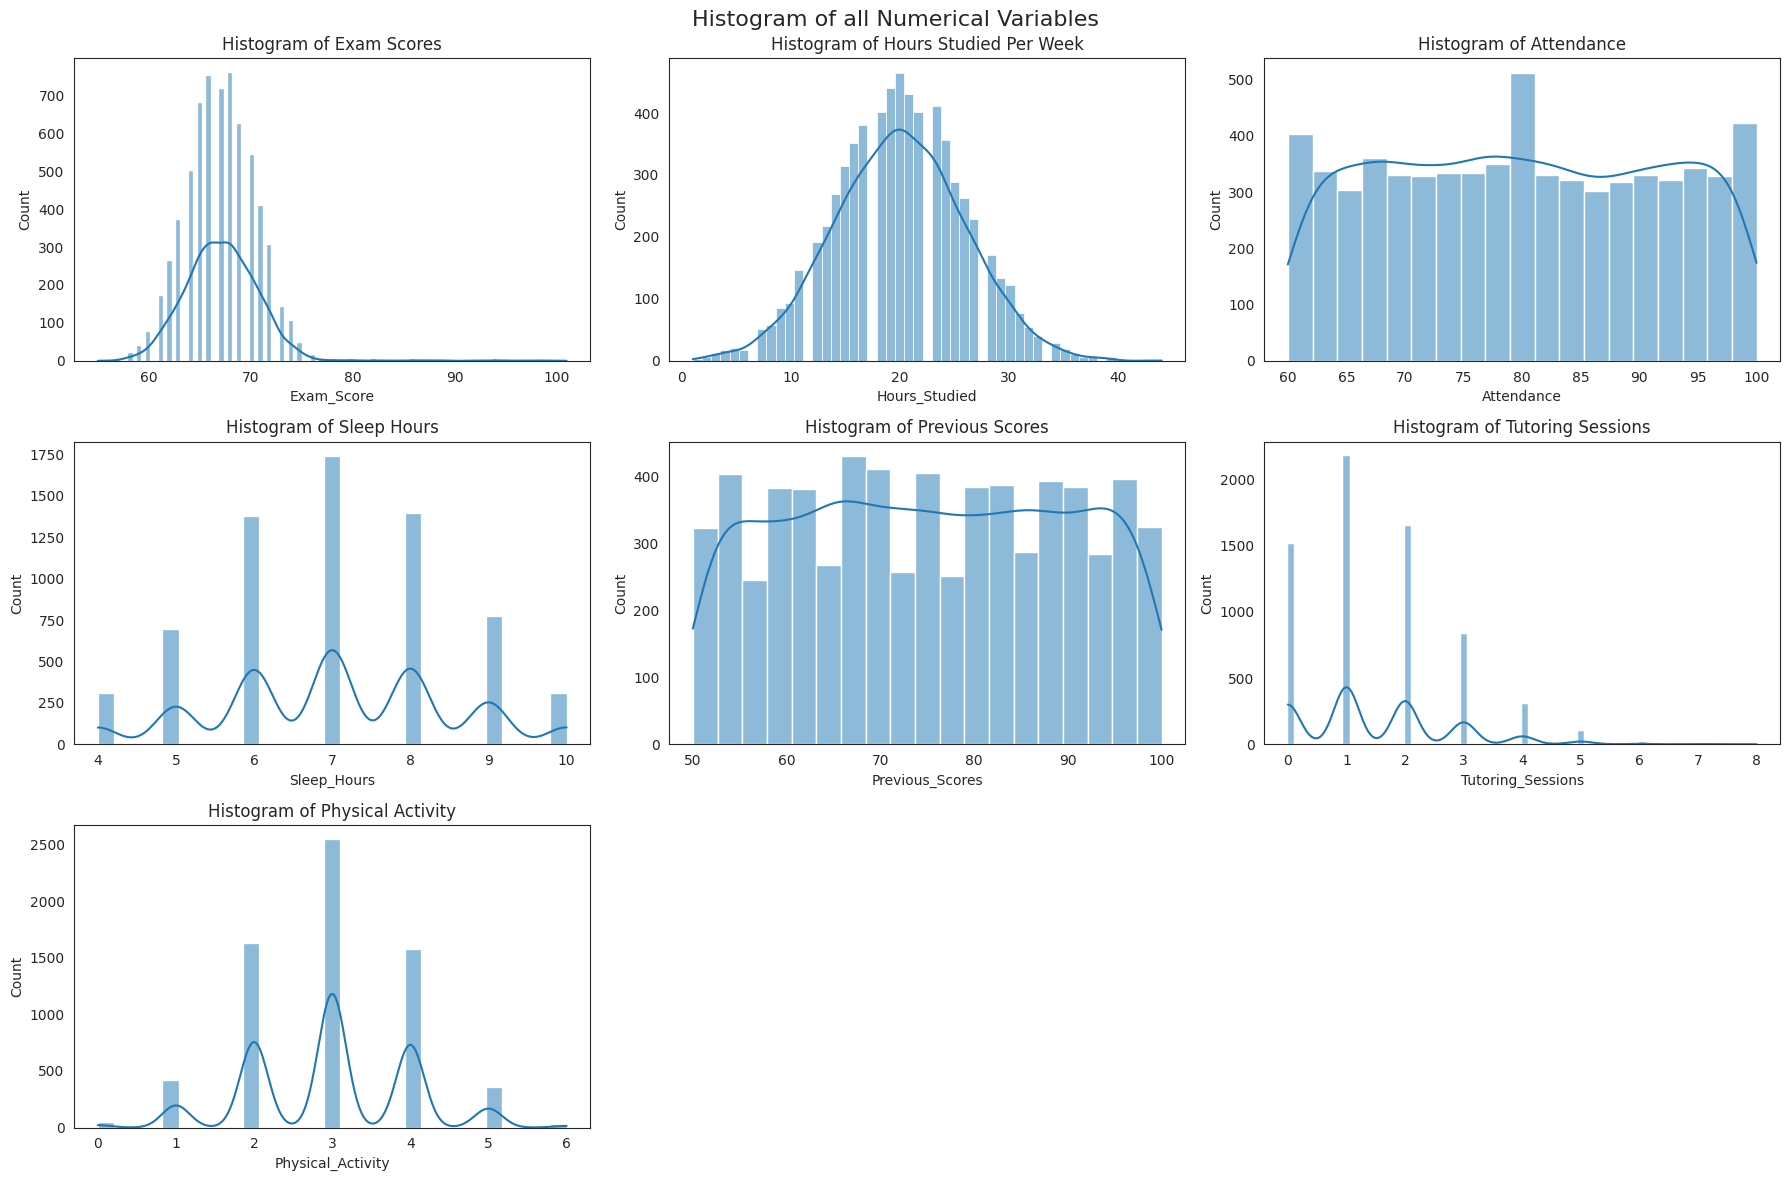

In [4]:
sns.set_style("white")

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(18, 12))
fig.suptitle("Histogram of all Numerical Variables", fontsize=16)

sns.histplot(data=df, x = "Exam_Score", ax=axes[0,0], kde=True).set_title("Histogram of Exam Scores")

sns.histplot(data=df, x = 'Hours_Studied', ax=axes[0,1], kde=True).set_title("Histogram of Hours Studied Per Week")

sns.histplot(data=df, x = 'Attendance', ax=axes[0,2], kde=True).set_title("Histogram of Attendance")

sns.histplot(data=df, x = 'Sleep_Hours', ax=axes[1,0], kde=True).set_title("Histogram of Sleep Hours")

sns.histplot(data=df, x = 'Previous_Scores', ax=axes[1,1], kde=True).set_title("Histogram of Previous Scores")

sns.histplot(data=df, x = 'Tutoring_Sessions', ax=axes[1,2], kde=True).set_title("Histogram of Tutoring Sessions")

sns.histplot(data=df, x = 'Physical_Activity', ax=axes[2,0], kde=True).set_title("Histogram of Physical Activity")

fig.delaxes(axes[2,1])
fig.delaxes(axes[2,2])

plt.tight_layout()
plt.show()

# Scatter Plots

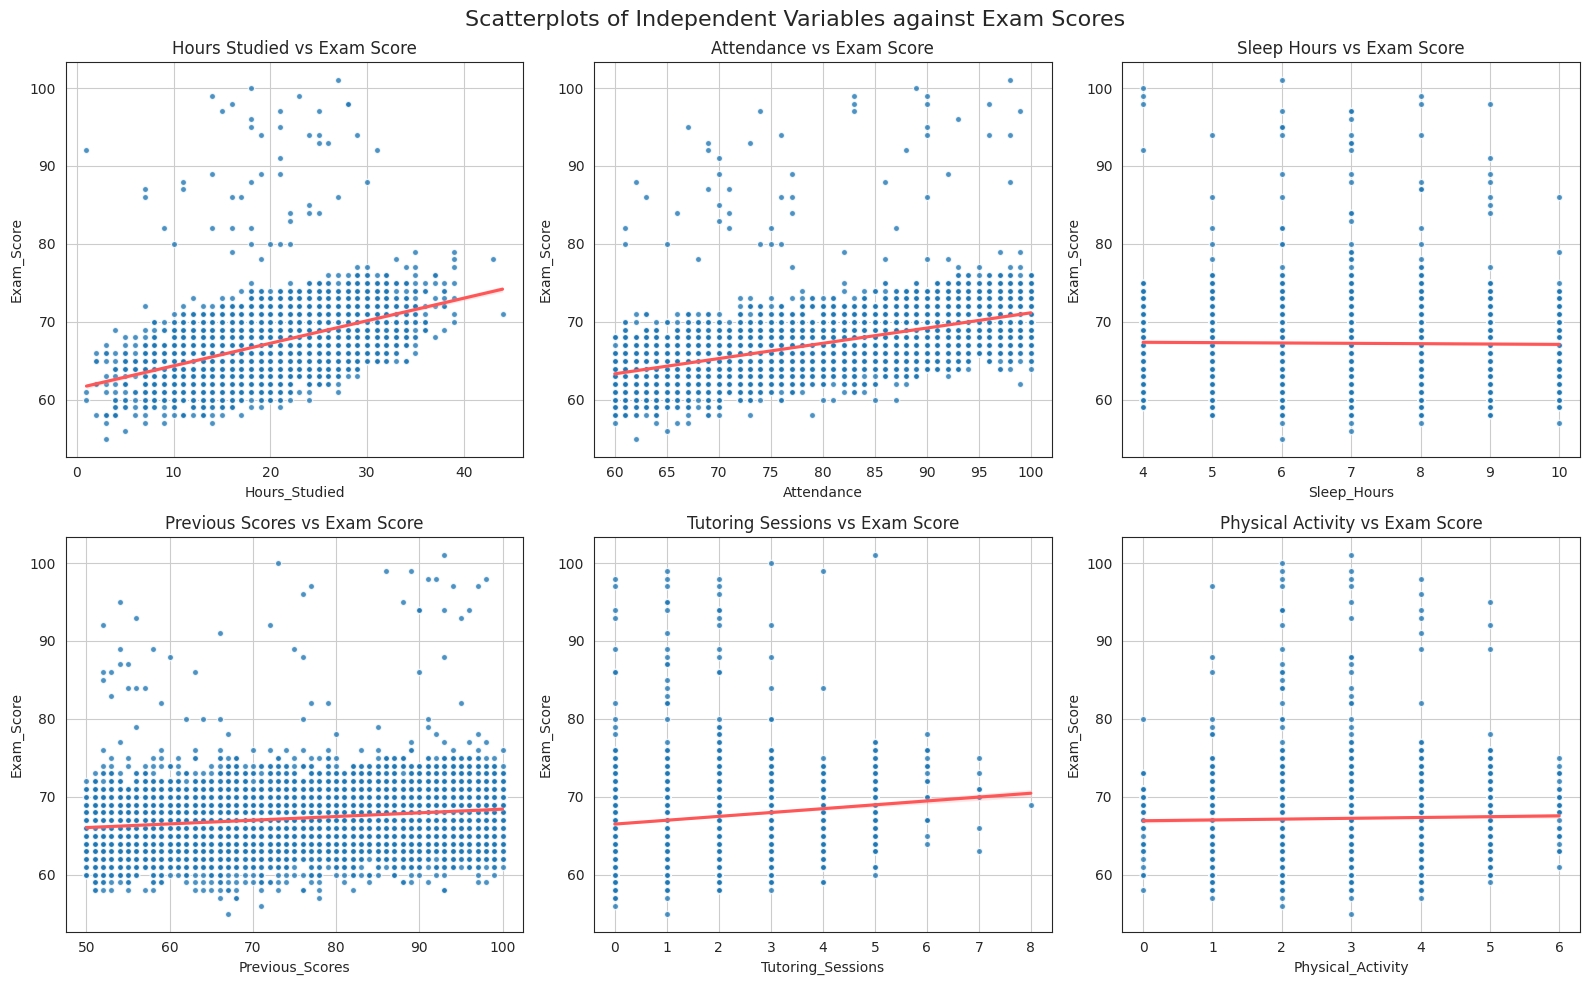

In [5]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 10))
for ax in axes.flat:
    ax.grid(True)

fig.suptitle("Scatterplots of Independent Variables against Exam Scores", fontsize=16)


sns.regplot(data=df, x = 'Hours_Studied', y = 'Exam_Score', ax=axes[0,0], line_kws={"color": '#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Hours Studied vs Exam Score")

sns.regplot(data=df, x = 'Attendance', y = 'Exam_Score', ax=axes[0,1], line_kws={"color":'#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Attendance vs Exam Score")

sns.regplot(data=df, x = 'Sleep_Hours', y = 'Exam_Score', ax=axes[0,2], line_kws={"color":'#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Sleep Hours vs Exam Score")

sns.regplot(data=df, x = 'Previous_Scores', y = 'Exam_Score', ax=axes[1,0], line_kws={"color":'#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Previous Scores vs Exam Score")

sns.regplot(data=df, x = 'Tutoring_Sessions', y = 'Exam_Score', ax=axes[1,1], line_kws={"color":'#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Tutoring Sessions vs Exam Score")

sns.regplot(data=df, x = 'Physical_Activity', y = 'Exam_Score', ax=axes[1,2], line_kws={"color":'#ff5757'}, 
            scatter_kws={'s':20, 'edgecolor':'white'}).set_title("Physical Activity vs Exam Score")


plt.tight_layout()
plt.show()

# Bar Plots/Charts

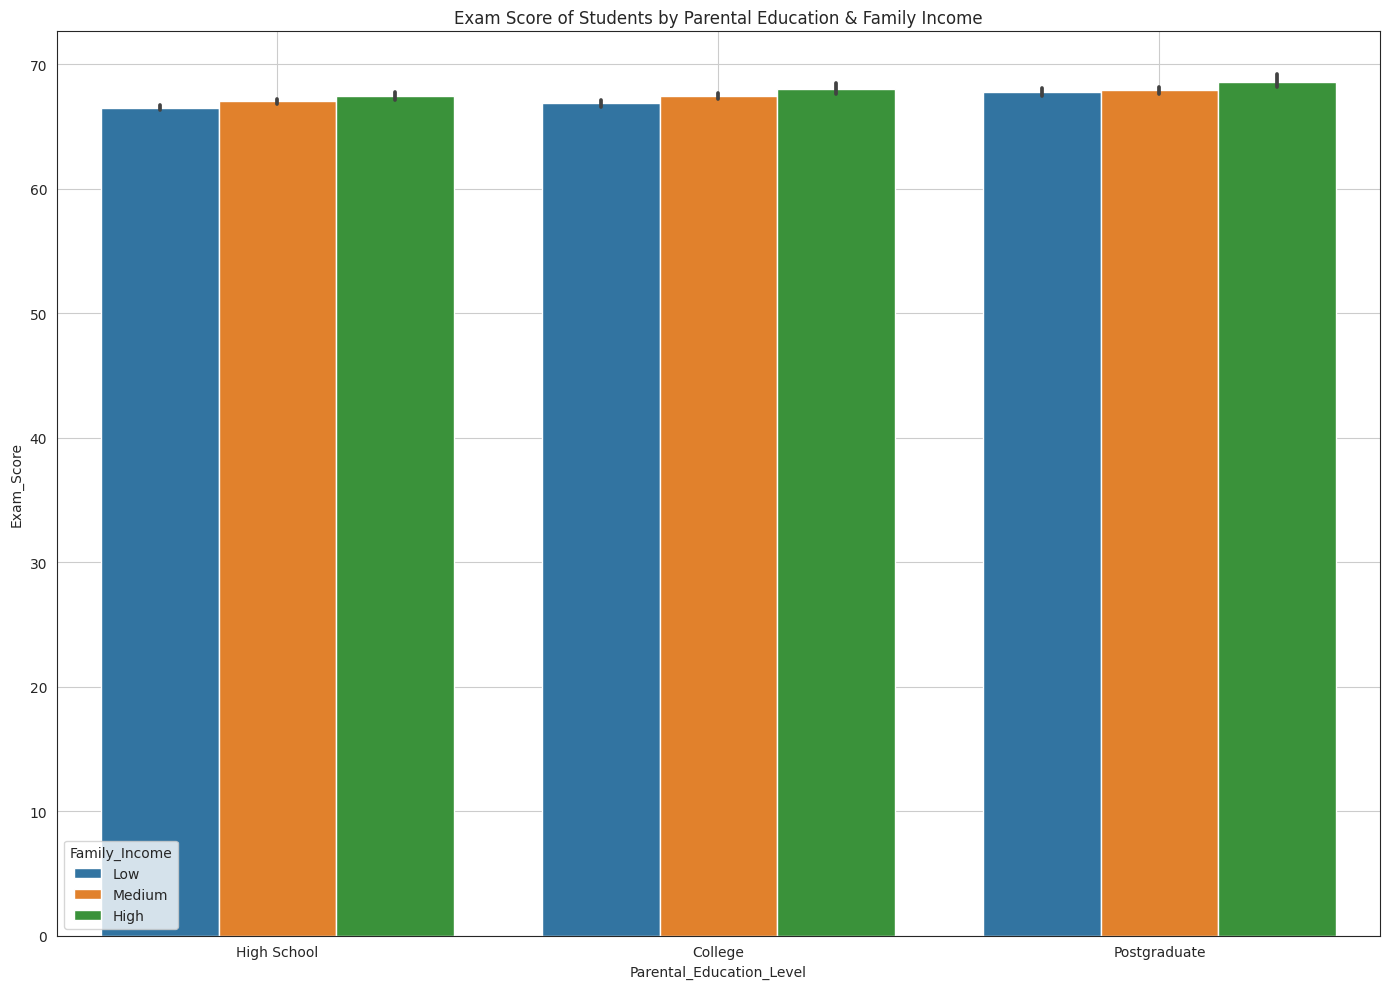

In [6]:
plt.figure(figsize=(14, 10))

sns.barplot(data=df, x = 'Parental_Education_Level', y = 'Exam_Score', hue='Family_Income').set_title("Exam Score of Students by Parental Education & Family Income")

plt.tight_layout()
plt.grid(True)
plt.show()

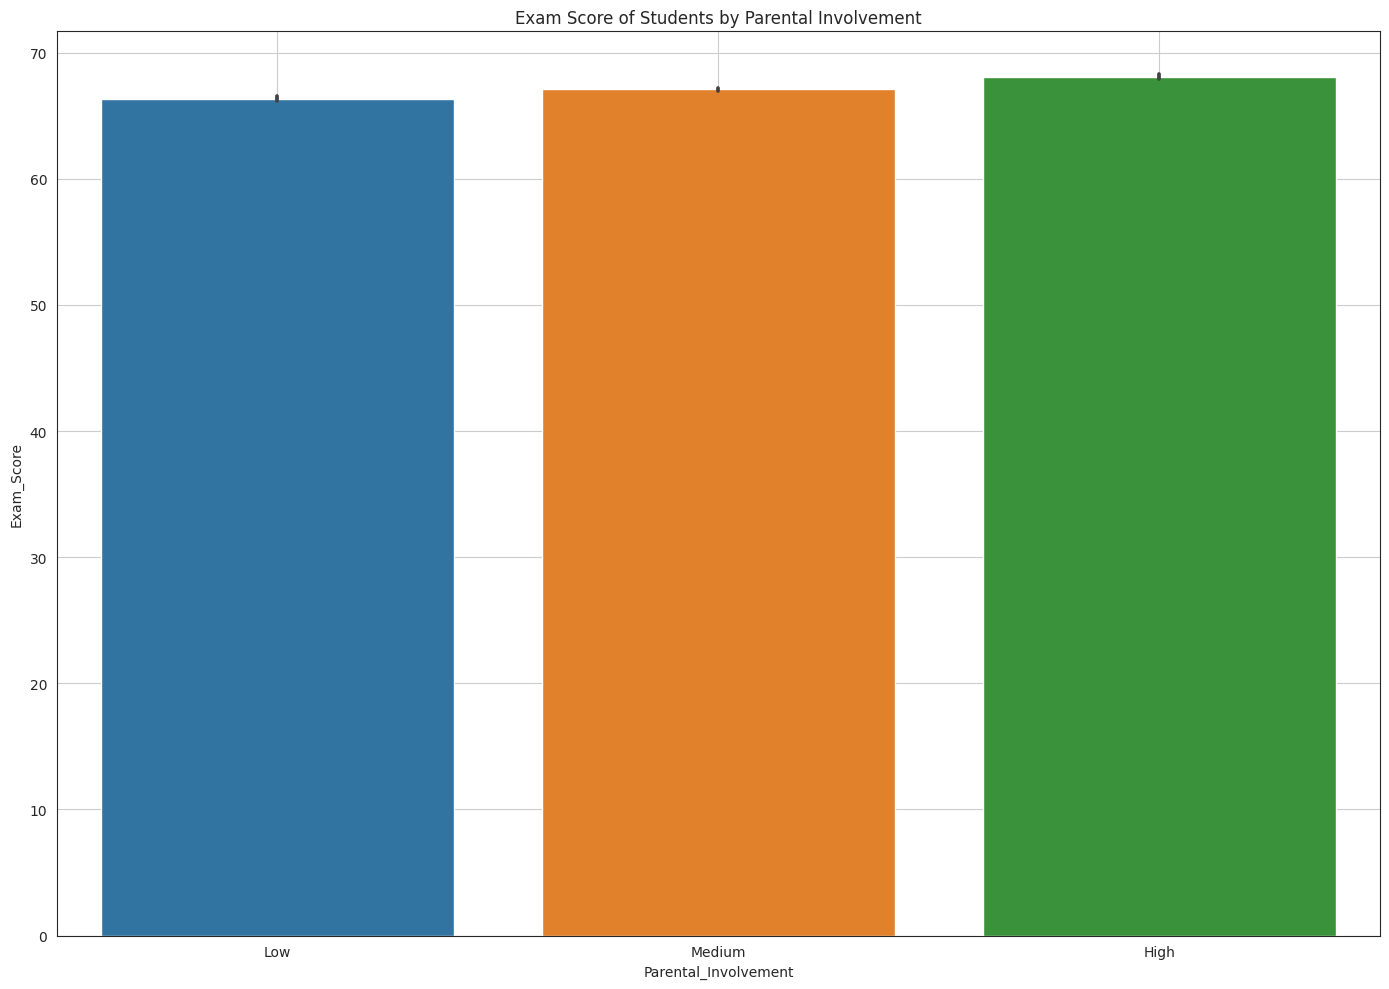

In [7]:
plt.figure(figsize=(14, 10))

sns.barplot(data=df, x = 'Parental_Involvement', y = 'Exam_Score').set_title("Exam Score of Students by Parental Involvement")

plt.tight_layout()
plt.grid(True)
plt.show()

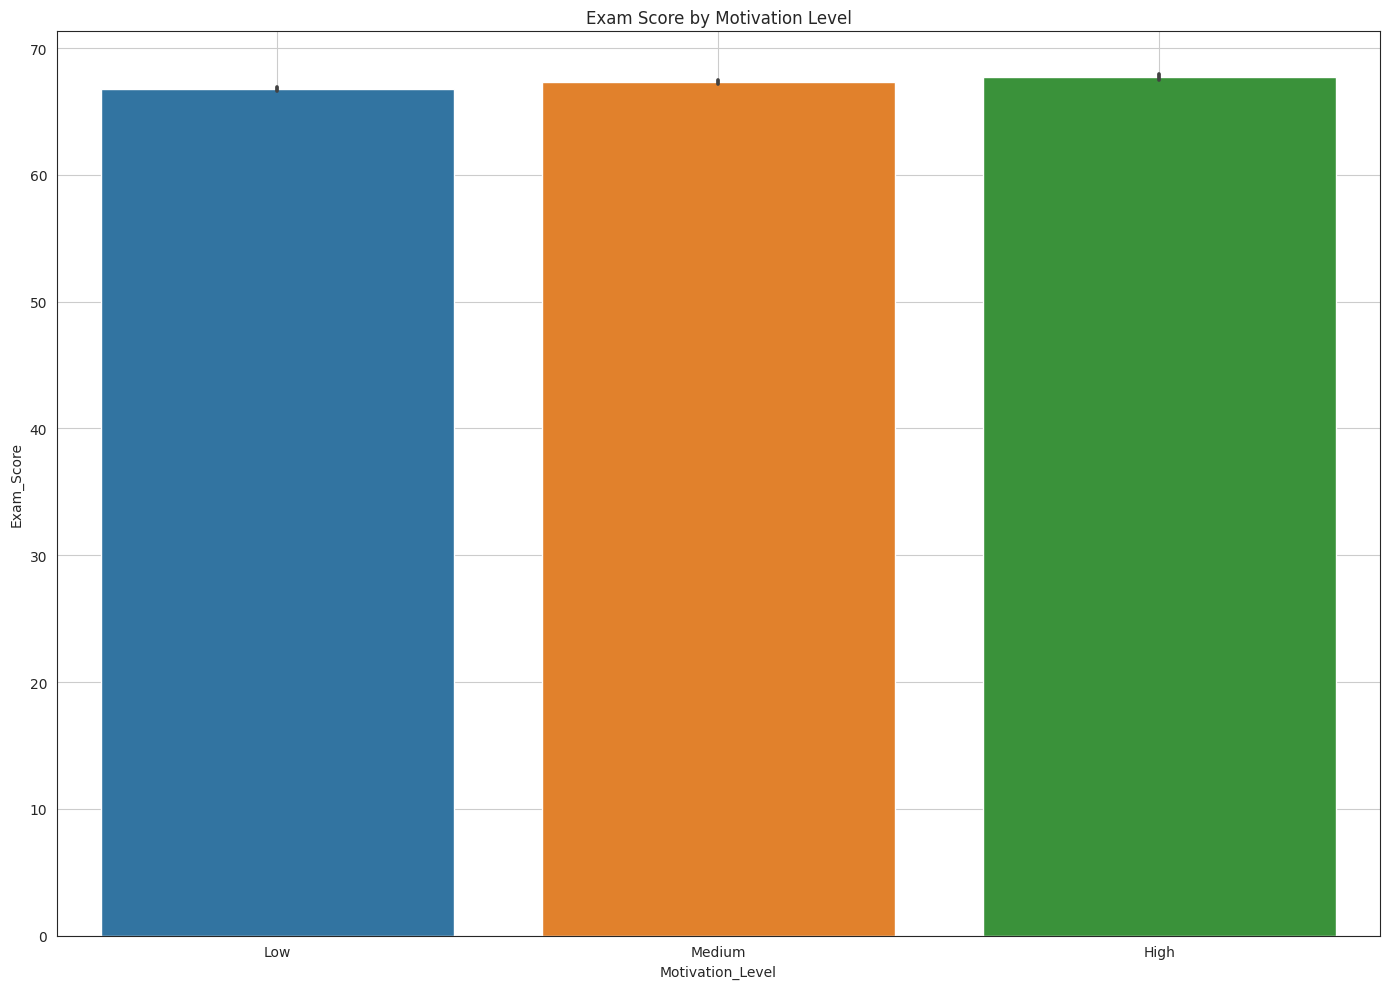

In [8]:
plt.figure(figsize=(14, 10))

sns.barplot(data=df, x = 'Motivation_Level', y = 'Exam_Score').set_title("Exam Score by Motivation Level")

plt.tight_layout()
plt.grid(True)
plt.show()

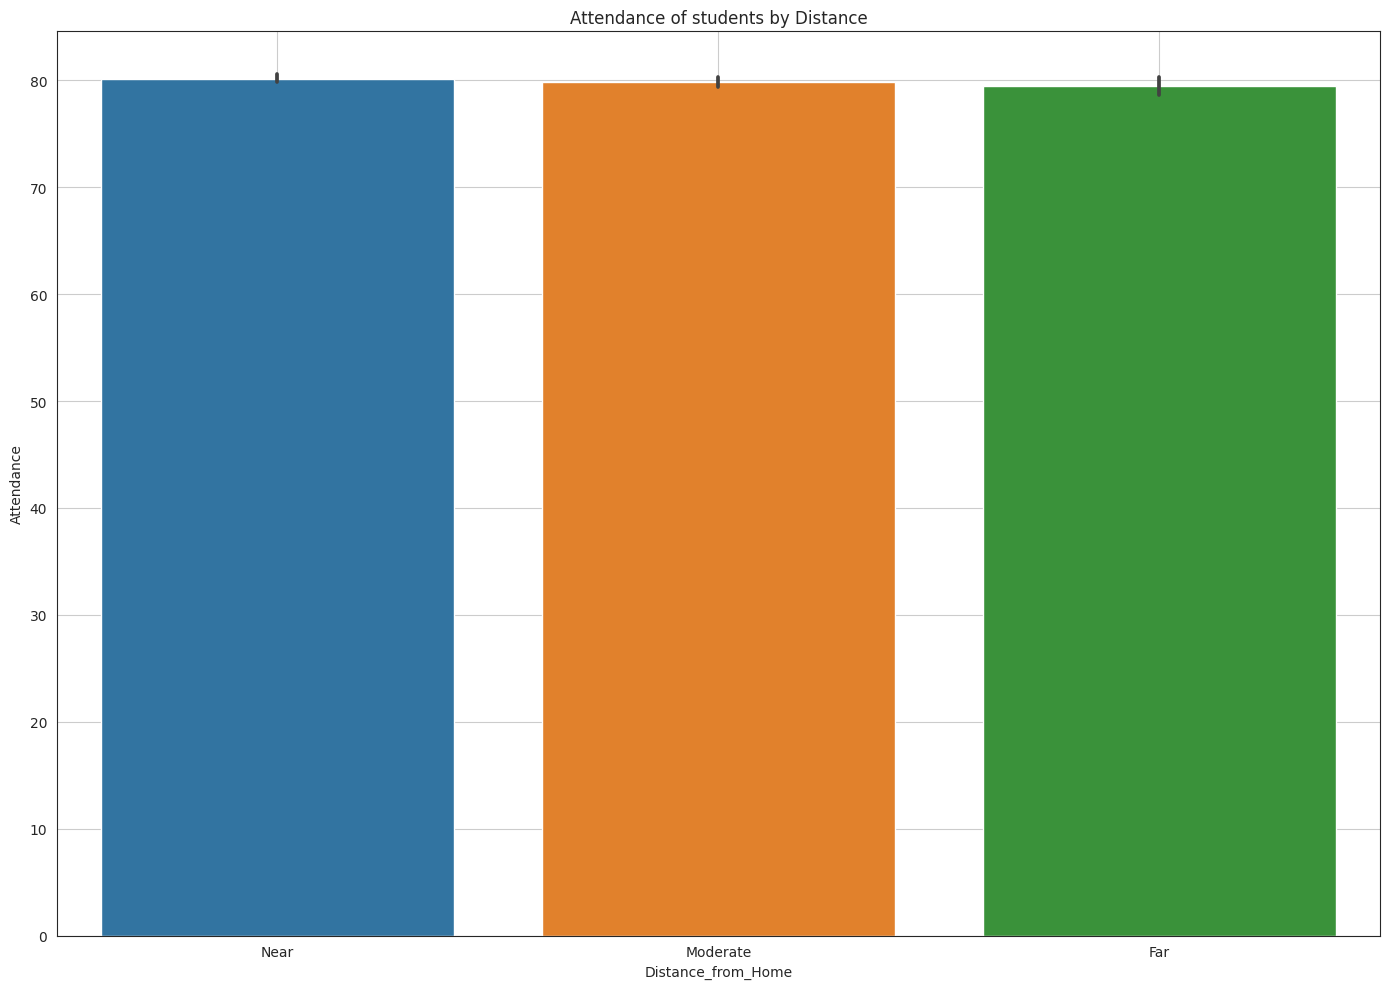

In [9]:
plt.figure(figsize=(14, 10))

sns.barplot(data=df, x = 'Distance_from_Home', y = 'Attendance').set_title("Attendance of students by Distance")

plt.tight_layout()
plt.grid(True)
plt.show()

# Heat Map 

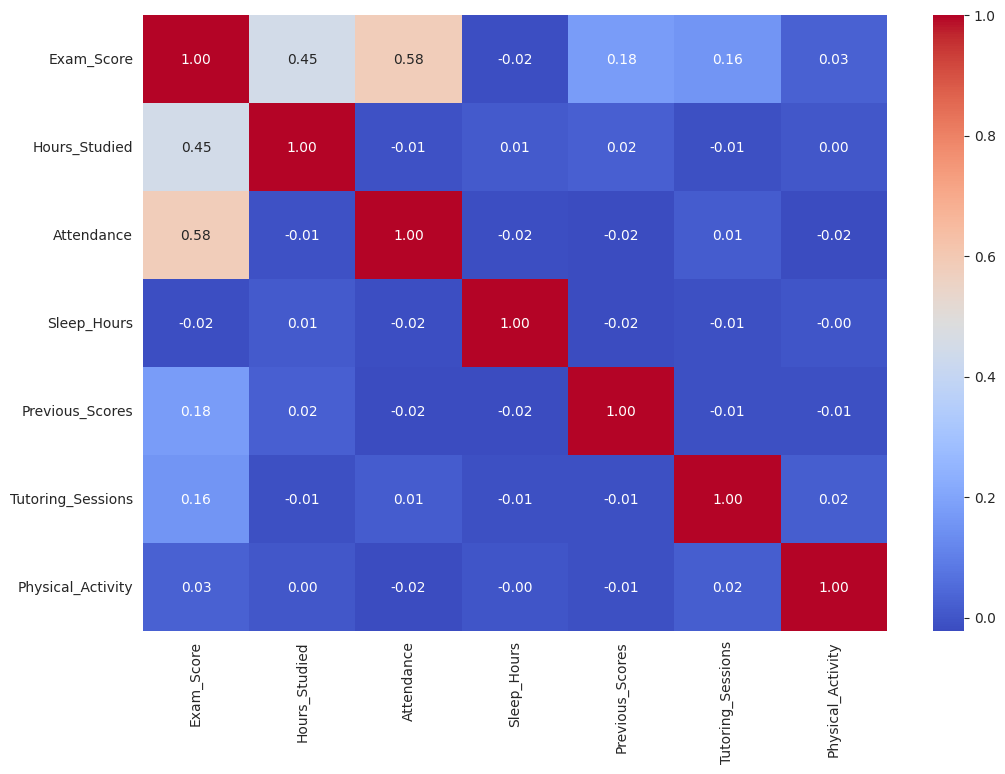

In [10]:
plt.figure(figsize=(12, 8))

corr_matrix = df[['Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']].corr()
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

# Machine Learning using OLS Regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

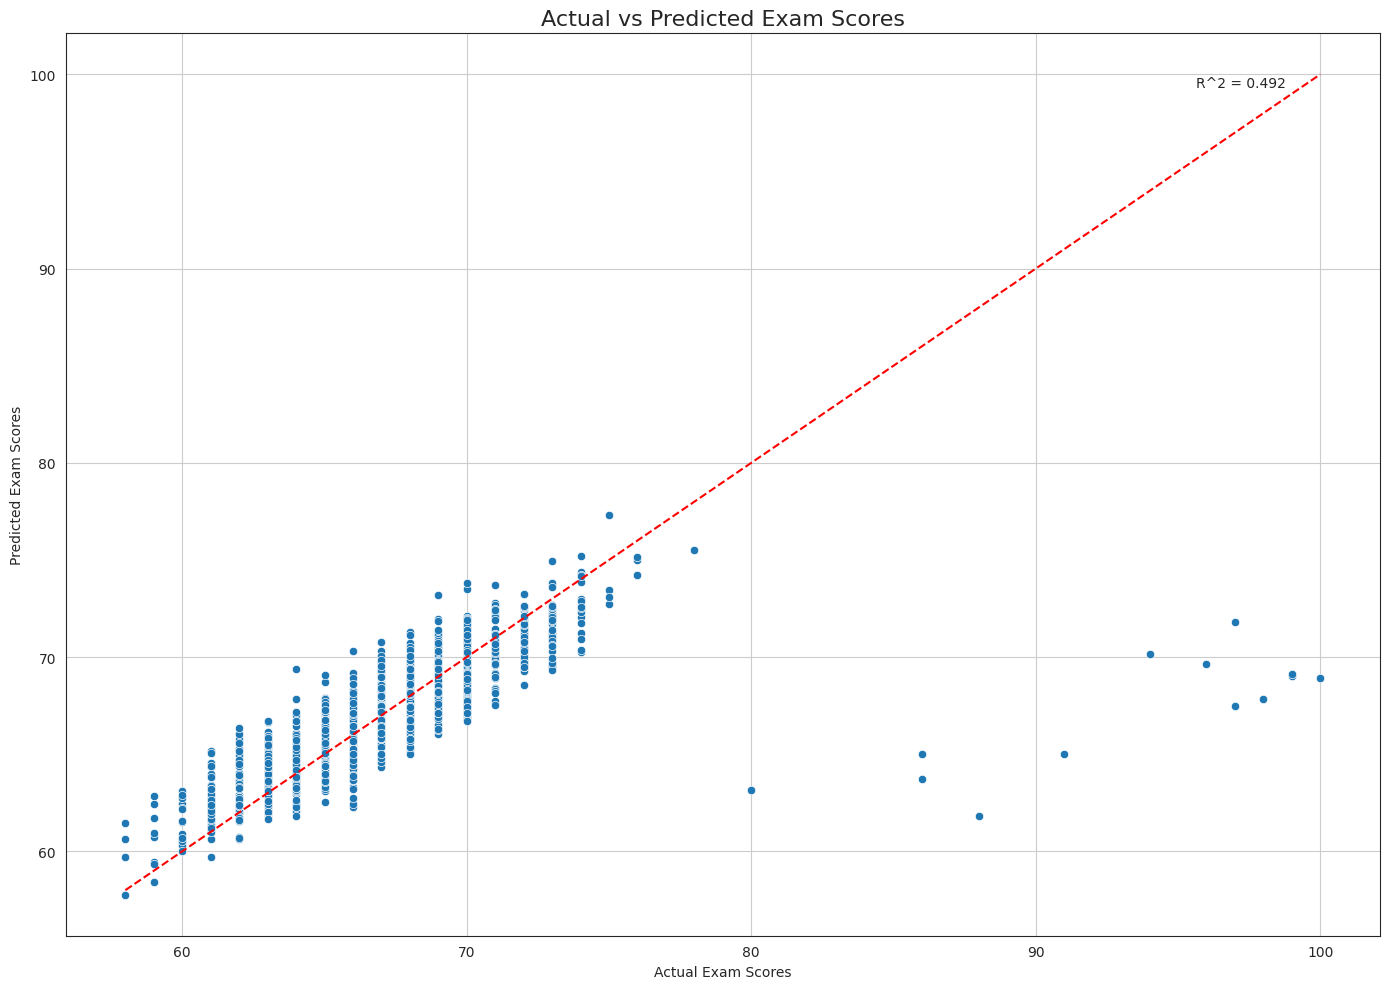

In [13]:
plt.figure(figsize=(14, 10))

sns.scatterplot(x = y_test, y = y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

r2 = r2_score(y_test, y_test_pred)
plt.text(0.86, 0.94, f'R^2 = {r2:.3f}', transform = plt.gca().transAxes)

plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()

All Done!